In [1]:
import os
import json
import torch
from tqdm import tqdm
from PIL import Image
from peft import PeftModel

from llava.model.builder import load_pretrained_model
from llava.mm_utils import (
    get_model_name_from_path,
    tokenizer_image_token,
    process_images
)
from llava.constants import IMAGE_TOKEN_INDEX
from llava.conversation import conv_templates

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ================= CONFIG (edit here if needed) =================
BASE_MODEL = "/root/autodl-tmp/llava-v1.5-7b"          # base LLaVA weights
LORA_PATH  = "/root/output/llava-vqa-rad-lora"         # your LoRA output dir (or checkpoint dir)
IMAGE_ROOT = "/root/data/VQA_RAD/images"         # folder that contains images

# Test splits (you said they are separated)
CLOSED_JSON = "/root/data/VQA_RAD/dataset_split/test_closed.json"
OPEN_JSON   = "/root/data/VQA_RAD/dataset_split/test_open.json"

# Cache predictions to avoid re-running slow inference
CACHE_DIR = "/root/output/llava_eval_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
CLOSED_CACHE = os.path.join(CACHE_DIR, "preds_test_closed.json")
OPEN_CACHE   = os.path.join(CACHE_DIR, "preds_test_open.json")


In [3]:
model_name = get_model_name_from_path(BASE_MODEL)

tokenizer, model, image_processor, context_len = load_pretrained_model(
    BASE_MODEL,
    None,
    model_name,
    device_map="cpu"      # ⭐ 关键：先全部在 CPU
)

if LORA_PATH is not None:
    model = PeftModel.from_pretrained(
        model,
        LORA_PATH,
        device_map="cpu"  # ⭐ LoRA 也在 CPU 注入
    )

model = model.cuda().eval()  # ⭐ 最后一次性上 GPU
print("✅ Model loaded")


You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


✅ Model loaded


In [4]:
@torch.no_grad()
@torch.inference_mode()
def llava_infer(sample):
    image = Image.open(
        os.path.join(IMAGE_ROOT, sample["image"])
    ).convert("RGB")

    image_tensor = process_images(
        [image], image_processor, model.config
    ).to(model.device, dtype=torch.float16)

    conv = conv_templates["llava_v1"].copy()
    conv.append_message(conv.roles[0], sample["conversations"][0]["value"])
    conv.append_message(conv.roles[1], None)

    prompt = conv.get_prompt()

    input_ids = tokenizer_image_token(
        prompt,
        tokenizer,
        IMAGE_TOKEN_INDEX,
        return_tensors="pt"
    ).unsqueeze(0).to(model.device)

    output_ids = model.generate(
        inputs=input_ids,     
        images=image_tensor,
        max_new_tokens=64,
        do_sample=False,
        temperature=0.0
    )

    return tokenizer.decode(
        output_ids[0], skip_special_tokens=True
    ).strip()


In [5]:
# ================= EVAL STEP 1: Run inference (or load cache) =================

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def get_q_gt(sample):
    q = sample["conversations"][0]["value"].replace("<image>", "").strip()
    gt = sample["conversations"][1]["value"]
    return q, gt

def infer_or_load(cache_path, data_path, desc):
    if os.path.exists(cache_path):
        print(f"✅ Load cache: {cache_path}")
        return load_json(cache_path)

    data = load_json(data_path)
    outs = []
    for s in tqdm(data, desc=desc):
        q, gt = get_q_gt(s)
        pred = llava_infer(s)  # uses IMAGE_ROOT + model
        outs.append({
            "id": s.get("id"),
            "image": s.get("image"),
            "question": q,
            "gt": gt,
            "pred": pred,
        })

    with open(cache_path, "w") as f:
        json.dump(outs, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved cache: {cache_path}")
    return outs

closed_out = infer_or_load(CLOSED_CACHE, CLOSED_JSON, "Infer TEST_CLOSED")
open_out   = infer_or_load(OPEN_CACHE, OPEN_JSON, "Infer TEST_OPEN")

print("CLOSED samples:", len(closed_out))
print("OPEN samples:", len(open_out))


Infer TEST_CLOSED:   0%|          | 0/260 [00:00<?, ?it/s]/root/miniconda3/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:392: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
Infer TEST_CLOSED: 100%|██████████| 260/260 [01:11<00:00,  3.63it/s]


✅ Saved cache: /root/output/llava_eval_cache/preds_test_closed.json


Infer TEST_OPEN: 100%|██████████| 191/191 [01:16<00:00,  2.50it/s]

✅ Saved cache: /root/output/llava_eval_cache/preds_test_open.json
CLOSED samples: 260
OPEN samples: 191


==== LLaVA CLOSED (test_closed.json) ====
Accuracy:       0.7269
Precision(yes): 0.7442
Recall(yes):    0.5664
F1(yes):        0.6432


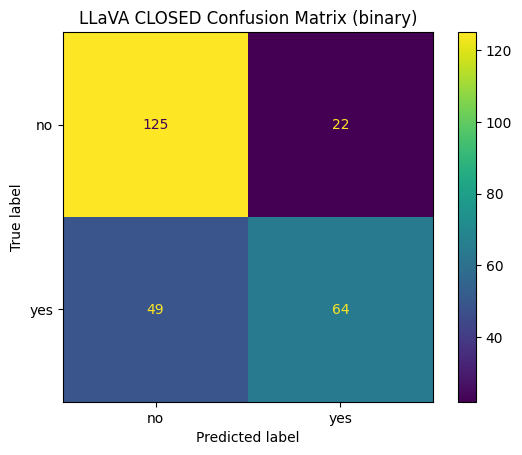

In [7]:
# ================= EVAL STEP 2: CLOSED (binary yes/no) =================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def norm_text(s: str):
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_yesno_binary(s: str):
    """Map model output / GT to binary yes/no.
    Rule: startswith('yes') => yes; otherwise => no.
    This makes evaluation robust to outputs like 'Yes.' / 'No evidence ...'.
    """
    s = norm_text(s)
    return "yes" if s.startswith("yes") else "no"

closed_gt = [norm_yesno_binary(x["gt"]) for x in closed_out]
closed_pd = [norm_yesno_binary(x["pred"]) for x in closed_out]

closed_acc = accuracy_score(closed_gt, closed_pd)
closed_precision = precision_score(closed_gt, closed_pd, pos_label="yes", zero_division=0)
closed_recall    = recall_score(closed_gt, closed_pd, pos_label="yes", zero_division=0)
closed_f1        = f1_score(closed_gt, closed_pd, pos_label="yes", zero_division=0)

print("==== LLaVA CLOSED (test_closed.json) ====")
print(f"Accuracy:       {closed_acc:.4f}")
print(f"Precision(yes): {closed_precision:.4f}")
print(f"Recall(yes):    {closed_recall:.4f}")
print(f"F1(yes):        {closed_f1:.4f}")

cm = confusion_matrix(closed_gt, closed_pd, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(cm, display_labels=["no", "yes"])
disp.plot()
plt.title("LLaVA CLOSED Confusion Matrix (binary)")
plt.show()


==== LLaVA OPEN (test_open.json) ====
Semantic Accuracy (Token-F1 ≥ 0.5): 0.4555
Mean Token-F1:                      0.4495


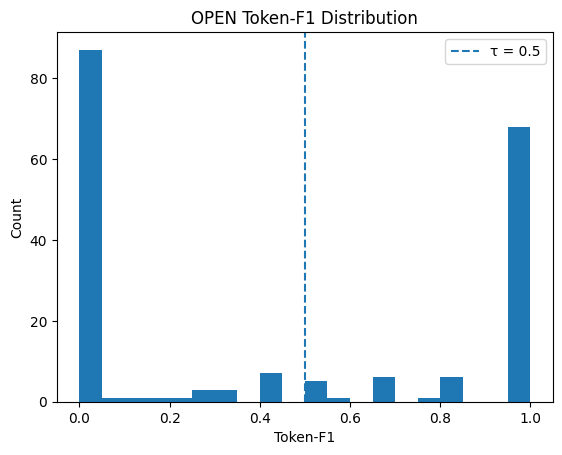


🎯 Correct predictions (sample):


,question,gt,pred,TokenF1,Correct(>=τ)
48,What are the two major organs present in this ...,Heart \tlungs,Lungs,0.666667,True
157,Where is the lateral ventricle?,left hemisphere,Left,0.666667,True
73,Where is the largest air collection in this im...,Right lung base,Right lung,0.800000,True
88,What is the name of the lesions seen in this i...,MS plaques,MS plaques,1.000000,True
125,What ventricle is the lesion compressing?,4th ventricle,4th ventricle,1.000000,True



❌ Incorrect predictions (sample):


,question,gt,pred,TokenF1,Correct(>=τ)
184,About how often do you see bilateral Wilms tumor?,5%,Not sure,0.000000,False
93,Which side is the diaphragm more depressed?,Left,Right,0.000000,False
181,What pathology is shown in the aorta?,It is enlarged with prominence of the aortic knob,Atherosclerotic calcification,0.000000,False
143,How big is the mass in cm?,2.5cm x 1.7cm x 1.6cm,3.4 cm,0.000000,False
42,How would you describe the pathology seen in t...,"Rounded, well-defined pulmonary nodules varyin...",Pulmonary nodules,0.333333,False


In [11]:
# ================= EVAL STEP 3: OPEN (Semantic Accuracy via Token-F1) =================
import re
import numpy as np
from collections import Counter
TAU = 0.5   # 推荐值：0.5（最常用、最好解释）
def normalize_open(s: str):
    """
    Normalize text for OPEN answer comparison:
    - lowercase
    - remove punctuation
    - collapse spaces
    """
    s = str(s).lower().strip()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def token_f1(pred: str, gt: str):
    """
    SQuAD-style Token-F1
    """
    pred_tokens = normalize_open(pred).split()
    gt_tokens   = normalize_open(gt).split()

    if len(pred_tokens) == 0 and len(gt_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

# ---- Compute Token-F1 for each OPEN sample ----
open_f1_scores = [token_f1(x["pred"], x["gt"]) for x in open_out]

# ---- Semantic Accuracy (Token-F1 >= tau) ----
open_semantic_acc = np.mean([f1 >= TAU for f1 in open_f1_scores])

print("==== LLaVA OPEN (test_open.json) ====")
print(f"Semantic Accuracy (Token-F1 ≥ {TAU}): {open_semantic_acc:.4f}")
print(f"Mean Token-F1:                      {float(np.mean(open_f1_scores)):.4f}")

# ---- Optional: distribution visualization (very useful for discussion) ----
import matplotlib.pyplot as plt

plt.figure()
plt.hist(open_f1_scores, bins=20)
plt.axvline(TAU, linestyle="--", label=f"τ = {TAU}")
plt.title("OPEN Token-F1 Distribution")
plt.xlabel("Token-F1")
plt.ylabel("Count")
plt.legend()
plt.show()

# ---- Optional: show some qualitative examples ----
import pandas as pd

df_open = pd.DataFrame({
    "question": [x["question"] for x in open_out],
    "gt": [x["gt"] for x in open_out],
    "pred": [x["pred"] for x in open_out],
    "TokenF1": open_f1_scores,
    "Correct(>=τ)": [f1 >= TAU for f1 in open_f1_scores],
})

print("\n🎯 Correct predictions (sample):")
display(
    df_open[df_open["Correct(>=τ)"]].sample(
        min(5, len(df_open[df_open["Correct(>=τ)"]]))
    )
)
print("\n❌ Incorrect predictions (sample):")
display(
    df_open[~df_open["Correct(>=τ)"]].sample(
        min(5, len(df_open[~df_open["Correct(>=τ)"]]))
    )
)